In [5]:
import numpy as np
import pandas as pd
import os
import kagglehub

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)
from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
path = kagglehub.dataset_download("rohanrao/formula-1-world-championship-1950-2020")

races_df = pd.read_csv(path + "/races.csv", na_values='\\N')
results_df = pd.read_csv(path + "/results.csv", na_values='\\N')
sprint_df = pd.read_csv(path + "/sprint_results.csv", na_values='\\N')
drivers_df = pd.read_csv(path + "/drivers.csv", na_values='\\N')
constructors_df = pd.read_csv(path + "/constructors.csv", na_values='\\N')
qualifying_df = pd.read_csv(path + "/qualifying.csv", na_values='\\N')

drivers_df['driver_name'] = drivers_df['forename'] + ' ' + drivers_df['surname']
results_df['position'] = pd.to_numeric(results_df['position'], errors='coerce')
results_df['grid'] = pd.to_numeric(results_df['grid'], errors='coerce')
sprint_df['position'] = pd.to_numeric(sprint_df['position'], errors='coerce')
sprint_df['grid'] = pd.to_numeric(sprint_df['grid'], errors='coerce')
qualifying_df['position'] = pd.to_numeric(qualifying_df['position'], errors='coerce')
sprint_race_ids = set(sprint_df['raceId'].unique())
races_df['is_sprint_weekend'] = races_df['raceId'].isin(sprint_race_ids)

100%|██████████| 6.28M/6.28M [00:00<00:00, 43.4MB/s]

Extracting files...


Sprint Placement vs. GP Placement at the Same Circuit

In [7]:
sprint_slim = sprint_df[['raceId', 'driverId', 'constructorId', 'position', 'grid']].copy()
sprint_slim = sprint_slim.rename(columns={
    'position': 'sprint_finish',
    'grid': 'sprint_grid'
})

gp_slim = results_df[['raceId', 'driverId', 'position', 'grid']].copy()
gp_slim = gp_slim.rename(columns={
    'position': 'gp_finish',
    'grid': 'gp_grid'
})
sprint_gp_df = (
    sprint_slim
    .merge(gp_slim, on=['raceId', 'driverId'], how='inner')
    .merge(races_df[['raceId', 'name', 'circuitId', 'year', 'round']], on='raceId')
    .merge(drivers_df[['driverId', 'driver_name']], on='driverId')
    .merge(
        constructors_df[['constructorId', 'name']].rename(columns={'name': 'team_name'}),
        on='constructorId'
    )
    .rename(columns={
        'name': 'race_name',
        'year': 'race_season',
        'round': 'race_round',
        'raceId': 'race_id',
        'driverId': 'driver_id',
        'circuitId': 'track_id'
    })
)
sprint_gp_clean = sprint_gp_df.dropna(subset=['sprint_finish', 'gp_finish']).copy()
sprint_gp_clean[[
    'race_name', 'race_season', 'driver_name', 'team_name',
    'sprint_grid', 'sprint_finish', 'gp_grid', 'gp_finish'
]].head(50) #change .head(num) here to show more, currently set this to 50

,race_name,race_season,driver_name,team_name,sprint_grid,sprint_finish,gp_grid,gp_finish
1,British Grand Prix,2021,Lewis Hamilton,Mercedes,1,2.0,2,1.0
2,British Grand Prix,2021,Valtteri Bottas,Mercedes,3,3.0,3,3.0
3,British Grand Prix,2021,Charles Leclerc,Ferrari,4,4.0,4,2.0
4,British Grand Prix,2021,Lando Norris,McLaren,6,5.0,5,4.0
5,British Grand Prix,2021,Daniel Ricciardo,McLaren,7,6.0,6,5.0
6,British Grand Prix,2021,Fernando Alonso,Alpine F1 Team,11,7.0,7,7.0
8,British Grand Prix,2021,George Russell,Williams,8,9.0,12,12.0
9,British Grand Prix,2021,Esteban Ocon,Alpine F1 Team,13,10.0,9,9.0
10,British Grand Prix,2021,Carlos Sainz,Ferrari,9,11.0,10,6.0
11,British Grand Prix,2021,Pierre Gasly,AlphaTauri,12,12.0,11,11.0


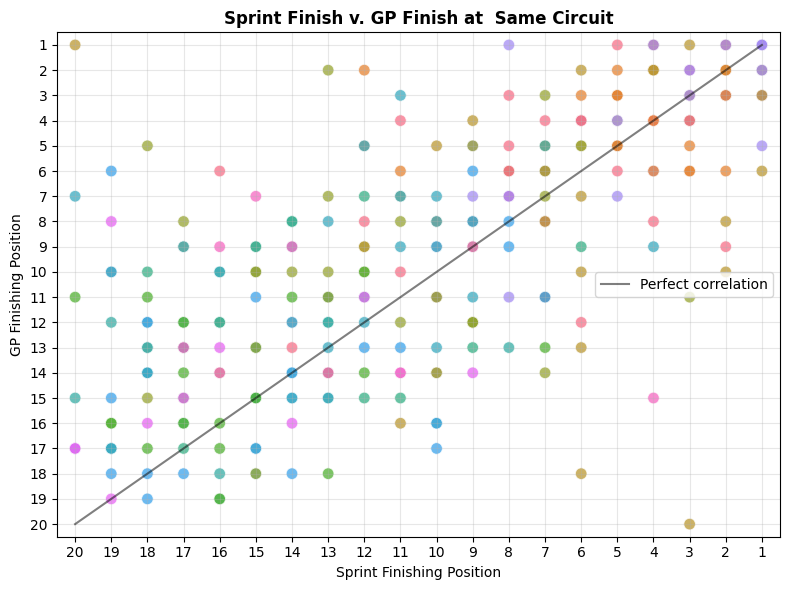

In [8]:
#sprint finish vs GP finish
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=sprint_gp_clean, x='sprint_finish', y='gp_finish',
    hue='team_name', alpha=0.75, s=70, legend=False
)
plt.plot([1, 20], [1, 20], 'k-', alpha=0.5, label='Perfect correlation')
plt.xlabel('Sprint Finishing Position')
plt.ylabel('GP Finishing Position')
plt.title('Sprint Finish v. GP Finish at  Same Circuit', fontweight='bold')
plt.xlim(20.5, 0.5)
plt.ylim(20.5, 0.5)
plt.xticks(range(1, 21))
plt.yticks(range(1, 21))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

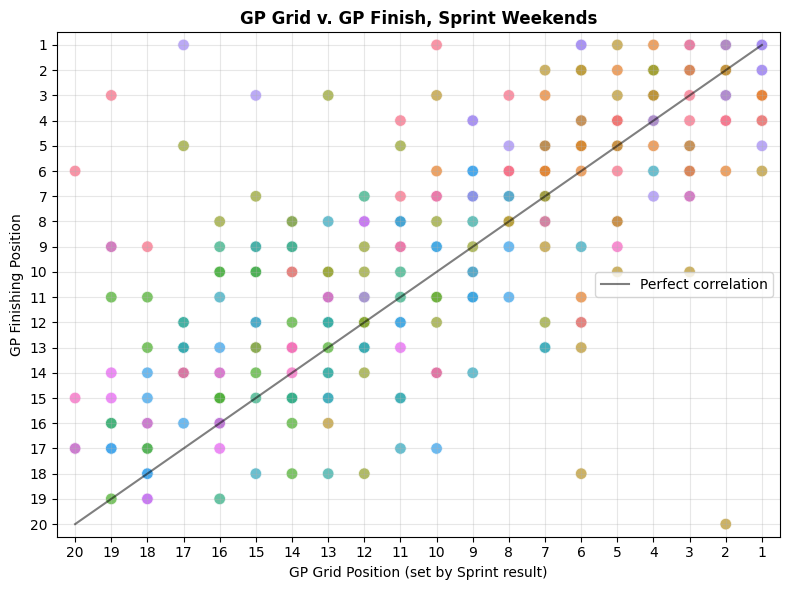

In [9]:
#comparing GP grid pos set by sprint to GP finish
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=sprint_gp_clean, x='gp_grid', y='gp_finish',
    hue='team_name', alpha=0.75, s=70, legend=False
)
plt.plot([1, 20], [1, 20], 'k-', alpha=0.5, label='Perfect correlation')
plt.xlabel('GP Grid Position (set by Sprint result)')
plt.ylabel('GP Finishing Position')
plt.title('GP Grid v. GP Finish, Sprint Weekends', fontweight='bold')
plt.xlim(20.5, 0.5)
plt.ylim(20.5, 0.5)
plt.xticks(range(1, 21))
plt.yticks(range(1, 21))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

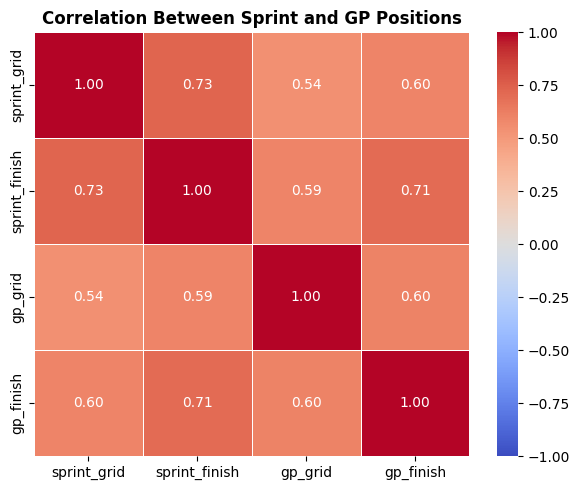

In [10]:
#see correlation between four key position columns
corr_cols = ['sprint_grid', 'sprint_finish', 'gp_grid', 'gp_finish']
corr_matrix = sprint_gp_clean[corr_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, linewidths=0.5
)
plt.title('Correlation Between Sprint and GP Positions', fontweight='bold')
plt.tight_layout()
plt.show()

Random firest regression to predict GP Finish from sprint result

using features sprint finishing position, sprint grid position, GP grid position, driver, team, track, season, round  
validation based on 80/20 train-test split with 5-fold GridSearchCV hyperparameter tuning

In [11]:
cat_features_rf = ['driver_id', 'team_name', 'track_id']
num_features_rf = ['sprint_finish', 'sprint_grid', 'gp_grid', 'race_round', 'race_season']
preprocessor_rf = ColumnTransformer(transformers=[
    ('numerical', StandardScaler(), num_features_rf),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), cat_features_rf)
])
X = sprint_gp_clean[cat_features_rf + num_features_rf]
y = sprint_gp_clean['gp_finish']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=5
)
print("For specifics so I don't forget:")
print("Training samples:", len(X_train), "| Test samples:", len(X_test))

For specifics so I don't forget:
Training samples: 236 | Test samples: 60


In [12]:
#tuning hyperparameters with gridsearchcv, scoring by MAE
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [3, 5, None],
    'regressor__min_samples_split': [2, 5]
}
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('regressor', RandomForestRegressor(random_state=5))
])

grid_search = GridSearchCV(
    rf_pipeline, param_grid,
    cv=5, scoring='neg_mean_absolute_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("best hyperparameters:", grid_search.best_params_)
print("Best cross-validation Mean absolute error:", round(-grid_search.best_score_, 3), "positions")
rf_best = grid_search.best_estimator_

best hyperparameters: {'regressor__max_depth': 5, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
Best cross-validation Mean absolute error: 2.665 positions


In [13]:
#random forest eevaluation based on training and test sets
y_train_pred = rf_best.predict(X_train)
y_test_pred = rf_best.predict(X_test)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Random Forest on Training MAE:", round(train_mae, 3), ", Test MAE:", round(test_mae, 3))
print("Random Forest on Training R2:", round(train_r2, 3), ", Test R2:", round(test_r2, 3))

Random Forest on Training MAE: 1.89 , Test MAE: 2.328
Random Forest on Training R2: 0.782 , Test R2: 0.682


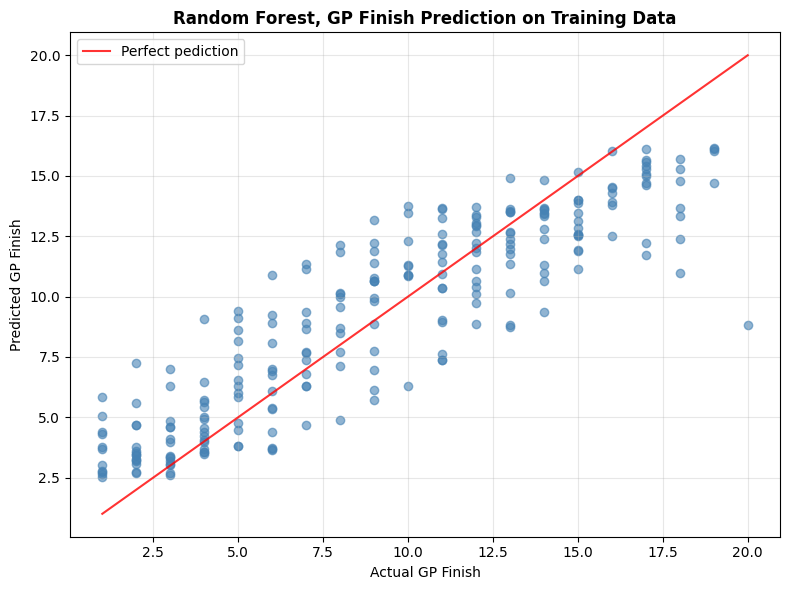

In [14]:
#training set, predicted v. actual
plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_train_pred, alpha=0.6, color='steelblue')
plt.plot([1, 20], [1, 20], 'r-', alpha=0.8, label='Perfect pediction')
plt.xlabel('Actual GP Finish')
plt.ylabel('Predicted GP Finish')
plt.title('Random Forest, GP Finish Prediction on Training Data', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

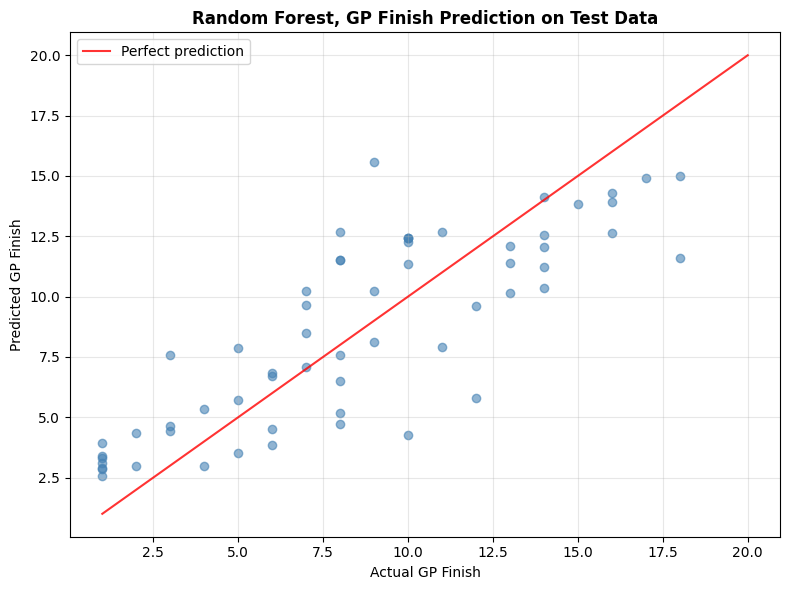

In [15]:
#test set, predicted v. actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, color='steelblue')
plt.plot([1, 20], [1, 20], 'r-', alpha=0.8, label='Perfect prediction')
plt.xlabel('Actual GP Finish')
plt.ylabel('Predicted GP Finish')
plt.title('Random Forest, GP Finish Prediction on Test Data', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

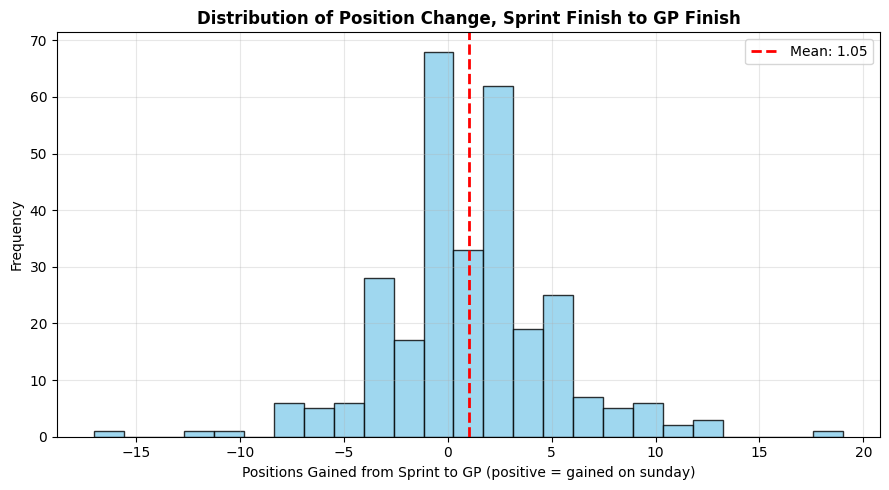

In [16]:
#see position change
sprint_gp_clean['sprint_to_gp_delta'] = (
    sprint_gp_clean['sprint_finish'] - sprint_gp_clean['gp_finish']
)
mean_delta = sprint_gp_clean['sprint_to_gp_delta'].mean()
plt.figure(figsize=(9, 5))
plt.hist(sprint_gp_clean['sprint_to_gp_delta'], bins=25,
         color='skyblue', edgecolor='black', alpha=0.8)
plt.axvline(mean_delta, color='red', linestyle='--', linewidth=2,
            label='Mean: ' + str(round(mean_delta, 2)))
plt.xlabel('Positions Gained from Sprint to GP (positive = gained on sunday)')
plt.ylabel('Frequency')
plt.title('Distribution of Position Change, Sprint Finish to GP Finish', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Sprint vs. Normal Qualifying GP Grid

In [17]:
#filter all sprint seasons
races_2122 = races_df[races_df['year'] >= 2021].copy()
print("2021 to 2024 race weekends:", len(races_2122))
print("Sprint weekends:", races_2122['is_sprint_weekend'].sum())
print("Normal weekends:", (~races_2122['is_sprint_weekend']).sum())
print()
print(races_2122[['year', 'round', 'name', 'is_sprint_weekend']].to_string(index=False))

2021 to 2024 race weekends: 90
Sprint weekends: 18
Normal weekends: 72

 year  round                      name  is_sprint_weekend
 2021      2 Emilia Romagna Grand Prix              False
 2022      1        Bahrain Grand Prix              False
 2021      1        Bahrain Grand Prix              False
 2021     20          Qatar Grand Prix              False
 2021      3     Portuguese Grand Prix              False
 2021      4        Spanish Grand Prix              False
 2021      5         Monaco Grand Prix              False
 2021      6     Azerbaijan Grand Prix              False
 2021      8        Styrian Grand Prix              False
 2021      7         French Grand Prix              False
 2021      9       Austrian Grand Prix              False
 2021     10        British Grand Prix               True
 2021     11      Hungarian Grand Prix              False
 2021     12        Belgian Grand Prix              False
 2021     13          Dutch Grand Prix              False


In [18]:
#build 21-24 GP result table, each race tagged as sprint or not
gp_2122 = (
    results_df
    .merge(
        races_2122[['raceId', 'year', 'round', 'name', 'circuitId', 'is_sprint_weekend']],
        on='raceId'
    )
    .merge(drivers_df[['driverId', 'driver_name']], on='driverId')
    .merge(
        constructors_df[['constructorId', 'name']].rename(columns={'name': 'team_name'}),
        on='constructorId'
    )
    .rename(columns={
        'name': 'race_name',
        'year': 'race_season',
        'round': 'race_round',
        'raceId': 'race_id',
        'driverId': 'driver_id',
        'circuitId': 'track_id'
    })
)
gp_2122['gp_grid'] = pd.to_numeric(gp_2122['grid'], errors='coerce')
gp_2122['gp_finish'] = pd.to_numeric(gp_2122['position'], errors='coerce')
print("Driver-race rows for 2021-2024:", len(gp_2122))
gp_2122[['race_name', 'driver_name', 'team_name', 'gp_grid', 'gp_finish', 'is_sprint_weekend']].head(1000) #change head num here to change total num of races shown, currently only 1000 shown (starting from 2021), max is 1799

Driver-race rows for 2021-2024: 1799


,race_name,driver_name,team_name,gp_grid,gp_finish,is_sprint_weekend
0,Bahrain Grand Prix,Lewis Hamilton,Mercedes,2,1.0,False
1,Bahrain Grand Prix,Max Verstappen,Red Bull,1,2.0,False
2,Bahrain Grand Prix,Valtteri Bottas,Mercedes,3,3.0,False
3,Bahrain Grand Prix,Lando Norris,McLaren,7,4.0,False
4,Bahrain Grand Prix,Sergio Pérez,Red Bull,0,5.0,False
...,...,...,...,...,...,...
995,Monaco Grand Prix,Sergio Pérez,Red Bull,20,16.0,False
996,Monaco Grand Prix,Nico Hülkenberg,Haas F1 Team,18,17.0,False
997,Monaco Grand Prix,Logan Sargeant,Williams,16,18.0,False
998,Monaco Grand Prix,Kevin Magnussen,Haas F1 Team,17,NaN,False


In [19]:
#avg GP grid pos for each driver, sprint vs normal
grid_by_format = (
    gp_2122
    .groupby(['driver_name', 'is_sprint_weekend'])['gp_grid']
    .mean()
    .unstack()
)
grid_by_format.columns = ['Normal Qualifying', 'Sprint Qualifying']
grid_by_format = grid_by_format.dropna()

#here negative delta means that driver qualifies better (results in a lower grid #) on sprint weekends
grid_by_format['delta'] = grid_by_format['Sprint Qualifying'] - grid_by_format['Normal Qualifying']
grid_by_format_sorted = grid_by_format.sort_values('delta')
print("Drivers who benefit most from sprint weekends (most negative delta = better sprint grid):")
print(grid_by_format_sorted.head(10).round(2).to_string()) #again you can change head num here to see more drivers, keeping 10 as baseline
print("\nDrivers who do better on normal qualifying weekends (positive delta = worse sprint grid):")
print(grid_by_format_sorted.tail(10).round(2).to_string())

Drivers who benefit most from sprint weekends (most negative delta = better sprint grid):
                    Normal Qualifying  Sprint Qualifying  delta
driver_name                                                    
Kimi Räikkönen                  14.17               6.50  -7.67
Nyck de Vries                   15.11               9.00  -6.11
Kevin Magnussen                 13.71              10.71  -3.00
Nico Hülkenberg                 11.81               8.83  -2.97
Lando Norris                     6.92               4.78  -2.14
Charles Leclerc                  5.58               3.50  -2.08
Lance Stroll                    12.88              11.11  -1.76
Mick Schumacher                 15.53              14.17  -1.36
Antonio Giovinazzi              13.00              11.67  -1.33
Yuki Tsunoda                    12.36              11.22  -1.14

Drivers who do better on normal qualifying weekends (positive delta = worse sprint grid):
                  Normal Qualifying  Sprint Qualify

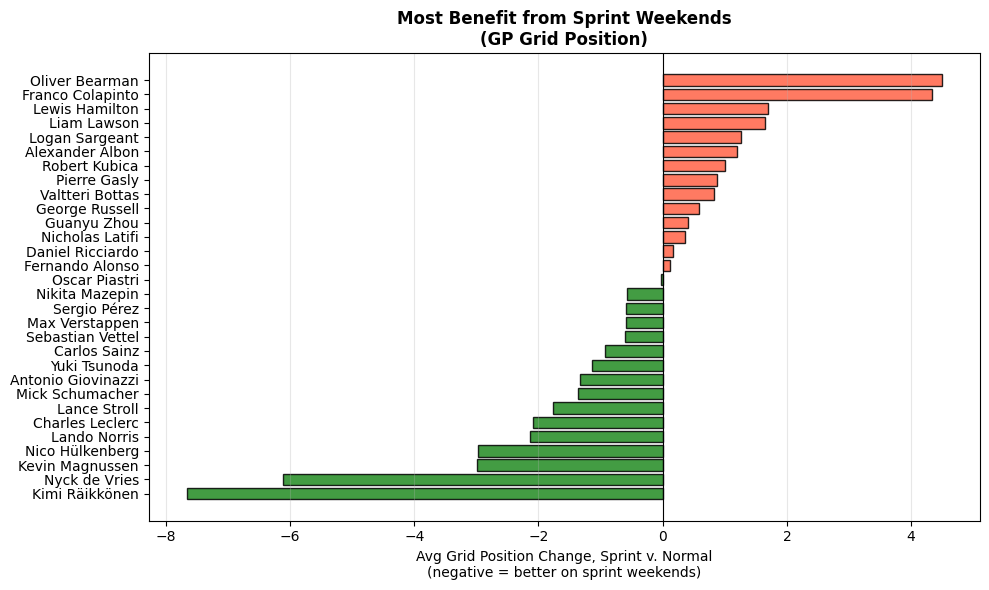

In [20]:
#see who is gaining or losing most avg grid pos in the sprint format
top_k = 30 #this num here can be changed to either increase/decrease num of drivers shown, altho 30 should be the max, this also influences other variables in data, specifically the .head and .tail
plot_data = grid_by_format_sorted['delta']
plot_subset = pd.concat([plot_data.head(top_k // 2), plot_data.tail(top_k // 2)])
colors = ['forestgreen' if v < 0 else 'tomato' for v in plot_subset]
plt.figure(figsize=(10, 6))
plt.barh(plot_subset.index, plot_subset.values, color=colors, edgecolor='black', alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Avg Grid Position Change, Sprint v. Normal\n(negative = better on sprint weekends)')
plt.title('Most Benefit from Sprint Weekends\n(GP Grid Position)', fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

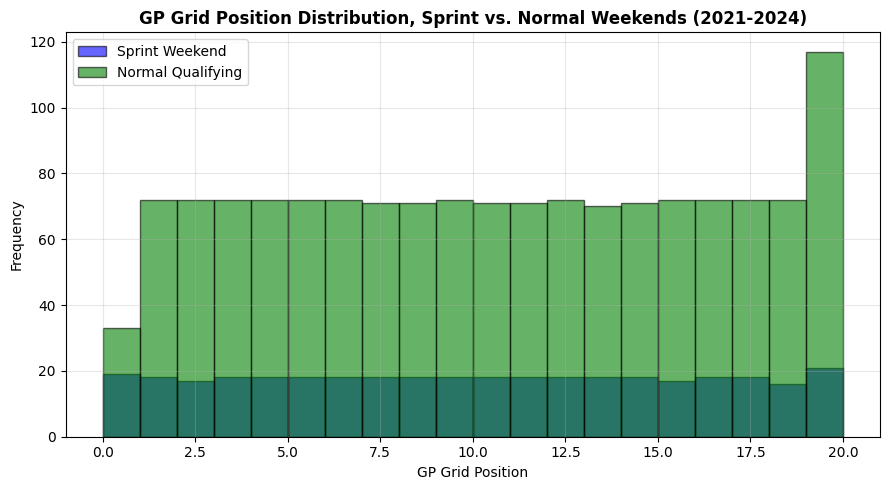

In [21]:
#distribution of GP grid positions, comparing sprints v. normal
sprint_grids = gp_2122[gp_2122['is_sprint_weekend']]['gp_grid'].dropna()
normal_grids = gp_2122[~gp_2122['is_sprint_weekend']]['gp_grid'].dropna()
plt.figure(figsize=(9, 5))
plt.hist(sprint_grids, bins=20, alpha=0.6, color='blue', edgecolor='black', label='Sprint Weekend')
plt.hist(normal_grids, bins=20, alpha=0.6, color='green', edgecolor='black', label='Normal Qualifying')
plt.xlabel('GP Grid Position')
plt.ylabel('Frequency')
plt.title('GP Grid Position Distribution, Sprint vs. Normal Weekends (2021-2024)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

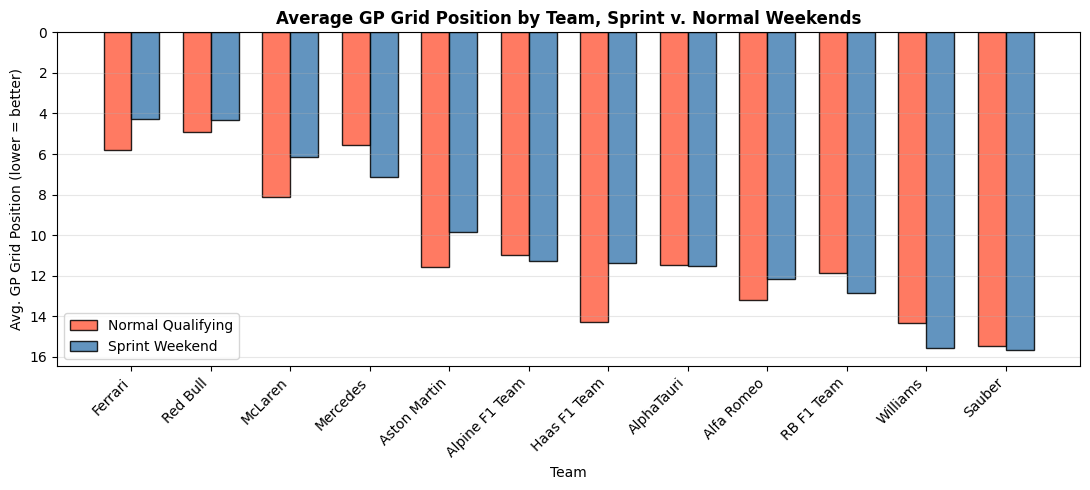

In [22]:
#comparing the teams now as well based on their avg GP grid pos, sprint v. normal
team_grid_compare = (
    gp_2122
    .groupby(['team_name', 'is_sprint_weekend'])['gp_grid']
    .mean()
    .unstack()
)
team_grid_compare.columns = ['Normal', 'Sprint']
team_grid_compare = team_grid_compare.dropna().sort_values('Sprint')

x = np.arange(len(team_grid_compare))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, team_grid_compare['Normal'], width,
       label='Normal Qualifying', color='tomato', edgecolor='black', alpha=0.85)
ax.bar(x + width/2, team_grid_compare['Sprint'], width,
       label='Sprint Weekend', color='steelblue', edgecolor='black', alpha=0.85)

ax.set_xlabel('Team')
ax.set_ylabel('Avg. GP Grid Position (lower = better)')
ax.set_title('Average GP Grid Position by Team, Sprint v. Normal Weekends', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(team_grid_compare.index, rotation=45, ha='right')
ax.invert_yaxis()
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Predicting Sprint Race Winners using Random Forest classifier

Features are sprint grid position, grid size, driver, team, track, round, season  
Our target is obviously sprint winner, where 1 = finished P1; 0 = did not win

In [23]:
#sprint results w all needed features as discussed above
sprint_full = (
    sprint_df
    .merge(races_df[['raceId', 'name', 'circuitId', 'year', 'round']], on='raceId')
    .merge(drivers_df[['driverId', 'driver_name']], on='driverId')
    .merge(
        constructors_df[['constructorId', 'name']].rename(columns={'name': 'team_name'}),
        on='constructorId'
    )
    .rename(columns={
        'raceId': 'race_id',
        'driverId': 'driver_id',
        'circuitId': 'track_id',
        'year': 'race_season',
        'round': 'race_round',
        'name': 'race_name',
        'position': 'sprint_finish',
        'grid': 'sprint_grid'
    })
)

sprint_full['sprint_grid_size'] = sprint_full.groupby('race_id')['driver_id'].transform('count')
sprint_full['sprint_winner'] = (sprint_full['sprint_finish'] == 1).astype(int)

print("Total sprint driver-race entries:", len(sprint_full))
print("Sprint winners (P1 finishes):", sprint_full['sprint_winner'].sum())
sprint_full[[
    'race_name', 'race_season', 'driver_name', 'team_name',
    'sprint_grid', 'sprint_finish', 'sprint_winner'
]].head(8) #and commented earlier throughout, change the .head number here to show more entries, right now just picking the top 8

Total sprint driver-race entries: 360
Sprint winners (P1 finishes): 18


,race_name,race_season,driver_name,team_name,sprint_grid,sprint_finish,sprint_winner
0,British Grand Prix,2021,Max Verstappen,Red Bull,2,1.0,1
1,British Grand Prix,2021,Lewis Hamilton,Mercedes,1,2.0,0
2,British Grand Prix,2021,Valtteri Bottas,Mercedes,3,3.0,0
3,British Grand Prix,2021,Charles Leclerc,Ferrari,4,4.0,0
4,British Grand Prix,2021,Lando Norris,McLaren,6,5.0,0
5,British Grand Prix,2021,Daniel Ricciardo,McLaren,7,6.0,0
6,British Grand Prix,2021,Fernando Alonso,Alpine F1 Team,11,7.0,0
7,British Grand Prix,2021,Sebastian Vettel,Aston Martin,10,8.0,0


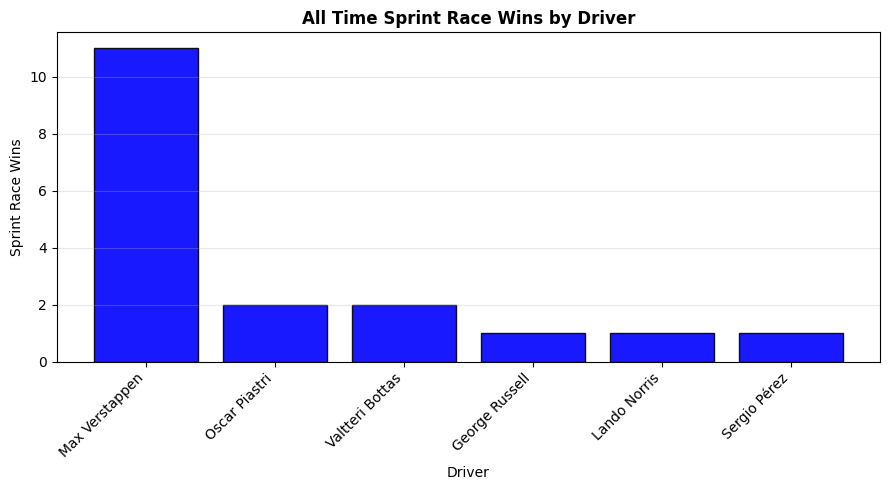

In [24]:
#all time sprint wins by driver
sprint_wins = (
    sprint_full[sprint_full['sprint_winner'] == 1]
    .groupby('driver_name').size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
plt.bar(sprint_wins.index, sprint_wins.values, color='blue', edgecolor='black', alpha=0.9)
plt.xlabel('Driver')
plt.ylabel('Sprint Race Wins')
plt.title('All Time Sprint Race Wins by Driver', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

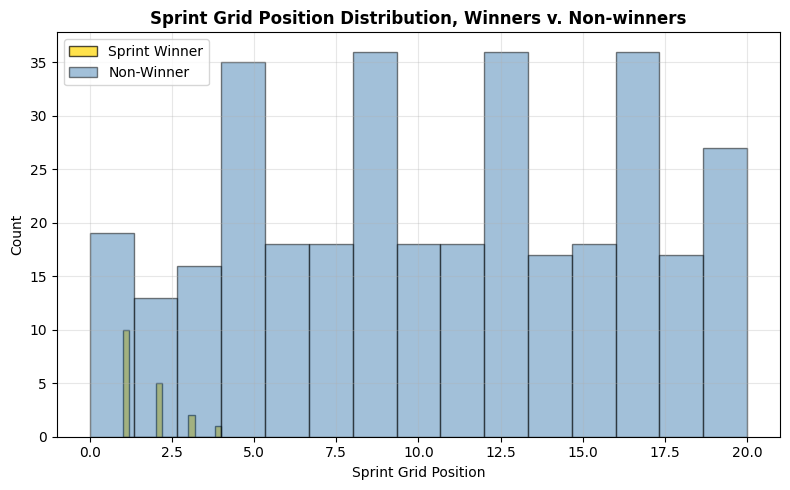

In [25]:
#sprint grid position distribution for winners v. those that didn't win
winners_grid = sprint_full[sprint_full['sprint_winner'] == 1]['sprint_grid'].dropna()
non_winners_grid = sprint_full[sprint_full['sprint_winner'] == 0]['sprint_grid'].dropna()

plt.figure(figsize=(8, 5))
plt.hist(winners_grid, bins=15, alpha=0.7, color='gold', edgecolor='black', label='Sprint Winner')
plt.hist(non_winners_grid, bins=15, alpha=0.5, color='steelblue', edgecolor='black', label='Non-Winner')
plt.xlabel('Sprint Grid Position')
plt.ylabel('Count')
plt.title('Sprint Grid Position Distribution, Winners v. Non-winners', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
#training the RF classifier to predict sprint winners
sprint_clf_df = sprint_full.dropna(subset=['sprint_grid']).copy()
cat_features_clf = ['driver_id', 'team_name', 'track_id']
num_features_clf = ['sprint_grid', 'sprint_grid_size', 'race_round', 'race_season']

preprocessor_clf = ColumnTransformer(transformers=[
    ('numerical', StandardScaler(), num_features_clf),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), cat_features_clf)
])

X_clf = sprint_clf_df[cat_features_clf + num_features_clf]
y_clf = sprint_clf_df['sprint_winner']
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf,
    test_size=0.20,
    random_state=5,
    stratify=y_clf #here just preserving the imbalanced class ratio
)

rf_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_clf),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        class_weight='balanced', #correct for ~5% winner class imbalance
        random_state=5
    ))
])
rf_clf_pipeline.fit(X_train_clf, y_train_clf)
y_train_clf_pred = rf_clf_pipeline.predict(X_train_clf)
y_test_clf_pred = rf_clf_pipeline.predict(X_test_clf)
print("Train accuracy:", round(accuracy_score(y_train_clf, y_train_clf_pred), 3))
print("Test accuracy:", round(accuracy_score(y_test_clf, y_test_clf_pred), 3))
print()
print(classification_report(y_test_clf, y_test_clf_pred, target_names=['Non-winner', 'Winner']))

Train accuracy: 0.986
Test accuracy: 0.931

              precision    recall  f1-score   support

  Non-winner       0.96      0.97      0.96        68
      Winner       0.33      0.25      0.29         4

    accuracy                           0.93        72
   macro avg       0.64      0.61      0.62        72
weighted avg       0.92      0.93      0.93        72



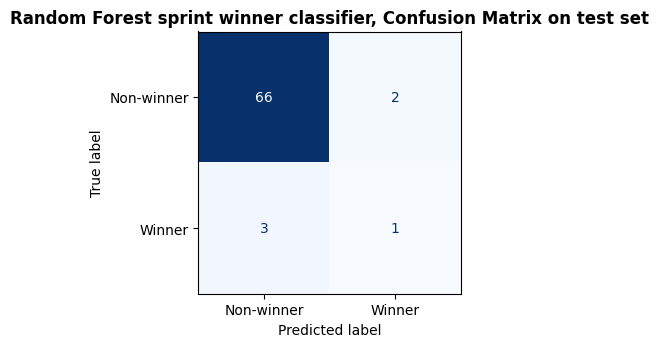

In [27]:
#Confusion matrix on the test set
fig, ax = plt.subplots(figsize=(4, 4))
cm_clf = confusion_matrix(y_test_clf, y_test_clf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_clf, display_labels=['Non-winner', 'Winner'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Random Forest sprint winner classifier, Confusion Matrix on test set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

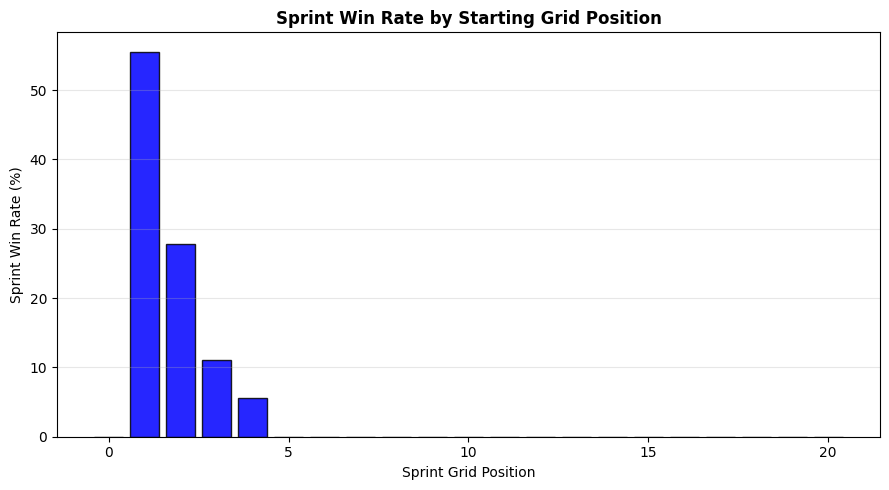

In [28]:
#win prob by grid pos, basically showing how strongly does the P1 grid predict a sprint win
win_rate_by_grid = sprint_clf_df.groupby('sprint_grid')['sprint_winner'].mean() * 100
plt.figure(figsize=(9, 5))
plt.bar(win_rate_by_grid.index, win_rate_by_grid.values,
        color='blue', edgecolor='black', alpha=0.85)
plt.xlabel('Sprint Grid Position')
plt.ylabel('Sprint Win Rate (%)')
plt.title('Sprint Win Rate by Starting Grid Position', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()